# Proyek Klasifikasi Gambar: Caltech 101
- **Nama:** Fika Saputri
- **Email:** fikasaputri818@gmail.com
- **ID Dicoding:** MC206D5X0930

 https://www.kaggle.com/datasets/imbikramsaha/caltech-101

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.18.0


## Data Preparation

In [3]:
# Import module yang disediakan google colab untuk kebutuhan upload file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fikasaputri","key":"37d6e323ef87760a9dec6781724f205d"}'}

In [4]:
# 1. Buat folder .kaggle dan pindahkan kaggle.json ke dalamnya
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# 2. Ubah permission agar file bisa dibaca oleh API
!chmod 600 ~/.kaggle/kaggle.json

# 3. Unduh dataset Caltech-101 dari Kaggle
!kaggle datasets download -d imbikramsaha/caltech-101

# 4. Ekstrak file zip-nya
!unzip caltech-101.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: caltech-101/ceiling_fan/image_0030.jpg  
  inflating: caltech-101/ceiling_fan/image_0031.jpg  
  inflating: caltech-101/ceiling_fan/image_0032.jpg  
  inflating: caltech-101/ceiling_fan/image_0033.jpg  
  inflating: caltech-101/ceiling_fan/image_0034.jpg  
  inflating: caltech-101/ceiling_fan/image_0035.jpg  
  inflating: caltech-101/ceiling_fan/image_0036.jpg  
  inflating: caltech-101/ceiling_fan/image_0037.jpg  
  inflating: caltech-101/ceiling_fan/image_0038.jpg  
  inflating: caltech-101/ceiling_fan/image_0039.jpg  
  inflating: caltech-101/ceiling_fan/image_0040.jpg  
  inflating: caltech-101/ceiling_fan/image_0041.jpg  
  inflating: caltech-101/ceiling_fan/image_0042.jpg  
  inflating: caltech-101/ceiling_fan/image_0043.jpg  
  inflating: caltech-101/ceiling_fan/image_0044.jpg  
  inflating: caltech-101/ceiling_fan/image_0045.jpg  
  inflating: caltech-101/ceiling_fan/image_0046.jpg  
  inflating: caltech-10

### Data Loading

In [5]:
from torchvision.datasets import ImageFolder

dataset_path = '/content/caltech-101'
all_data = ImageFolder(root=dataset_path)

print(f"Jumlah total gambar: {len(all_data)}")
print(f"Jumlah kelas terdeteksi: {len(all_data.classes)}")
print(f"Nama-nama kelas: {all_data.classes[:10]}")  # contoh 10 kelas pertama


Jumlah total gambar: 9144
Jumlah kelas terdeteksi: 102
Nama-nama kelas: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel']


BACKGROUND_Google: 467 gambar
Faces: 435 gambar
Faces_easy: 435 gambar
Leopards: 200 gambar
Motorbikes: 798 gambar
accordion: 55 gambar
airplanes: 800 gambar
anchor: 42 gambar
ant: 42 gambar
barrel: 47 gambar
bass: 54 gambar
beaver: 46 gambar
binocular: 33 gambar
bonsai: 128 gambar
brain: 98 gambar
brontosaurus: 43 gambar
buddha: 85 gambar
butterfly: 91 gambar
camera: 50 gambar
cannon: 43 gambar
car_side: 123 gambar
ceiling_fan: 47 gambar
cellphone: 59 gambar
chair: 62 gambar
chandelier: 107 gambar
cougar_body: 47 gambar
cougar_face: 69 gambar
crab: 73 gambar
crayfish: 70 gambar
crocodile: 50 gambar
crocodile_head: 51 gambar
cup: 57 gambar
dalmatian: 67 gambar
dollar_bill: 52 gambar
dolphin: 65 gambar
dragonfly: 68 gambar
electric_guitar: 75 gambar
elephant: 64 gambar
emu: 53 gambar
euphonium: 64 gambar
ewer: 85 gambar
ferry: 67 gambar
flamingo: 67 gambar
flamingo_head: 45 gambar
garfield: 34 gambar
gerenuk: 34 gambar
gramophone: 51 gambar
grand_piano: 99 gambar
hawksbill: 100 gambar
h

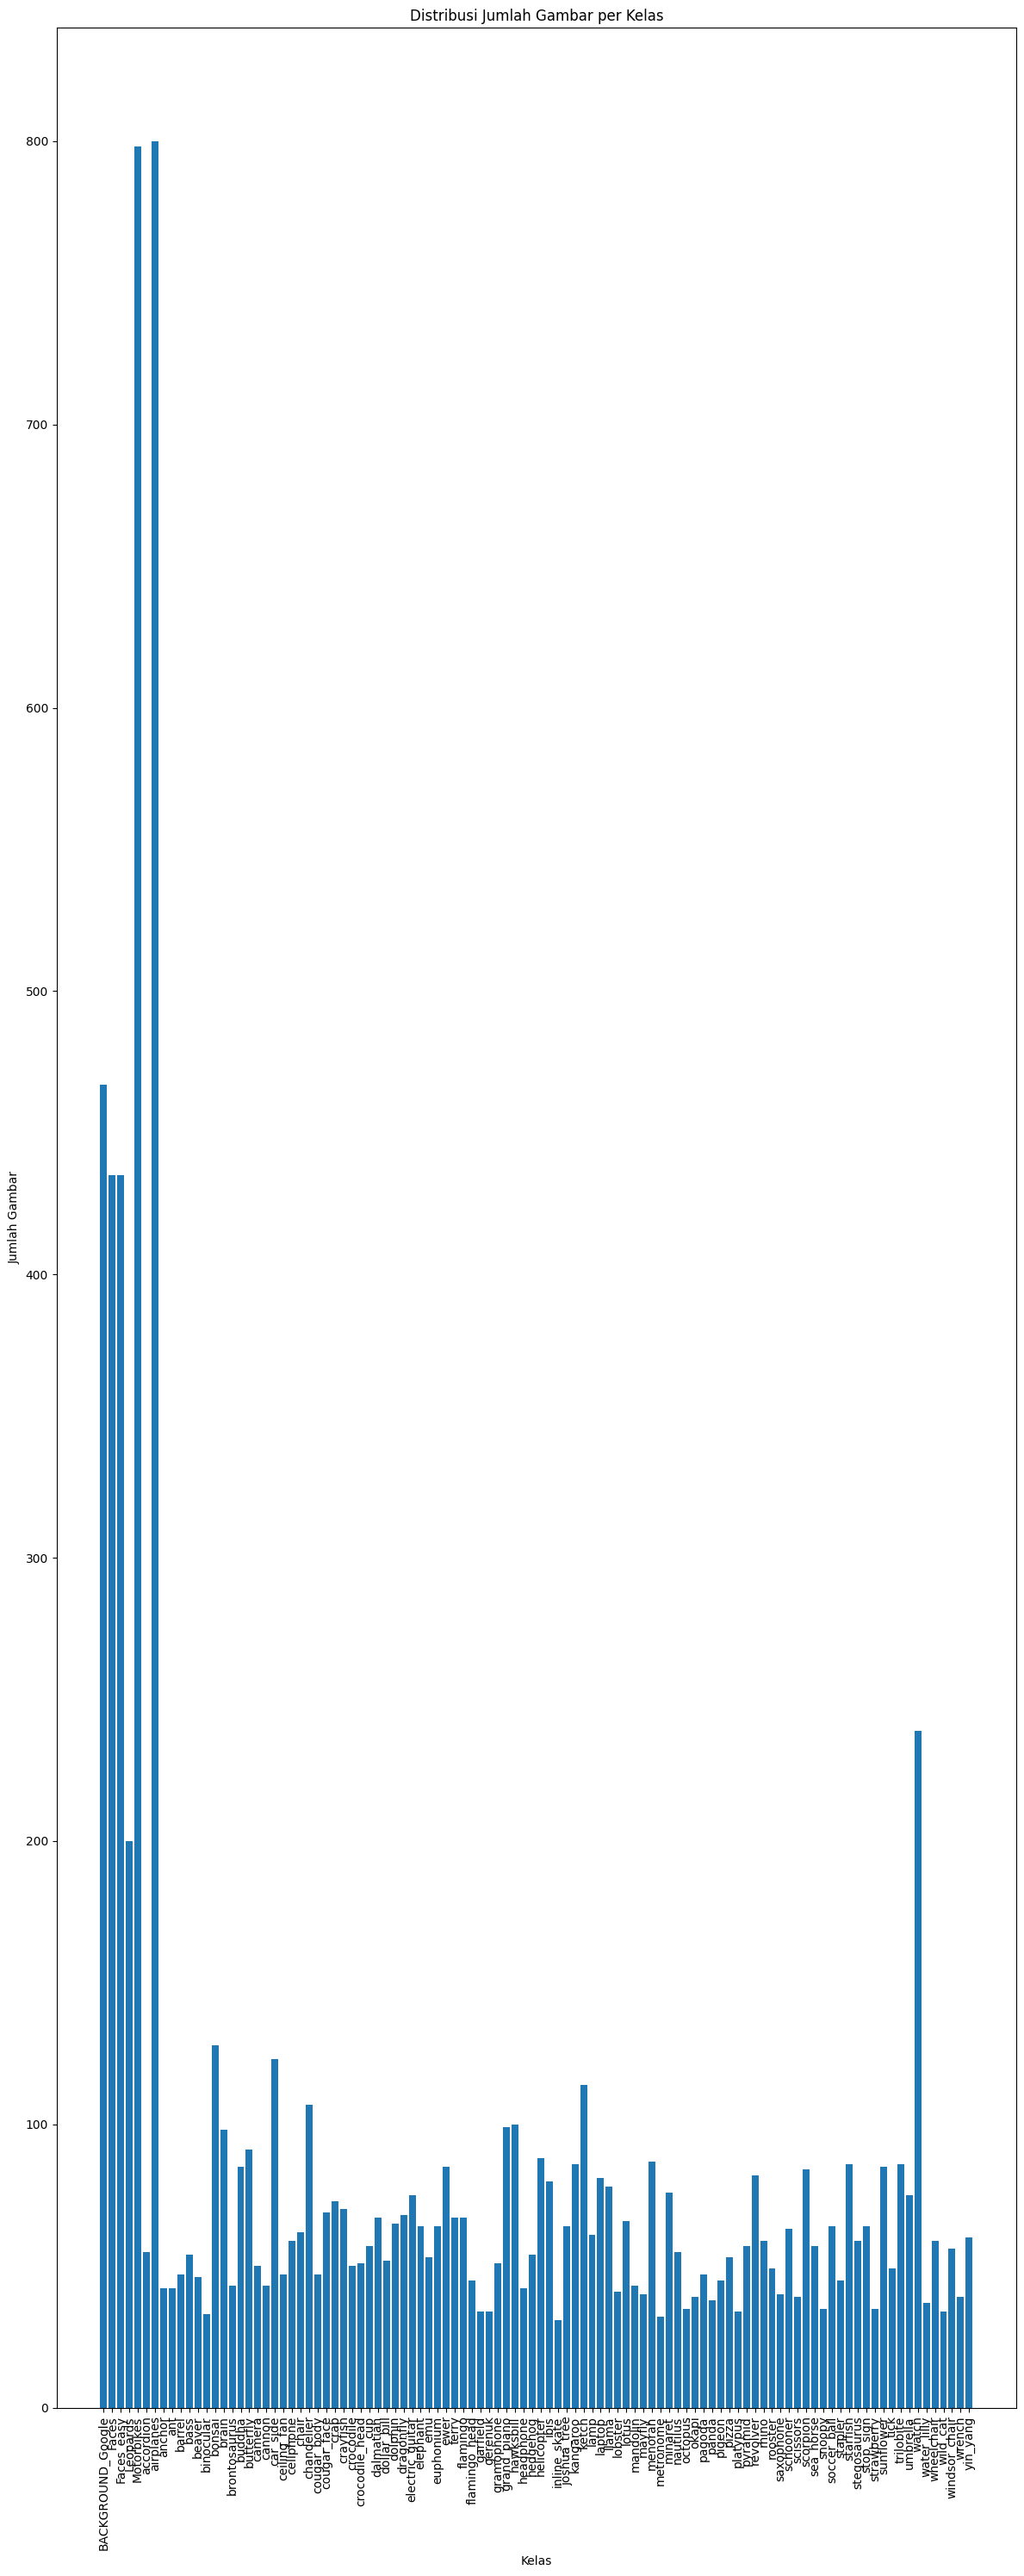

In [6]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Hitung jumlah gambar per kelas
class_counts = defaultdict(int)

for _, label in all_data.samples:
    class_counts[label] += 1

# Mapping label index ke nama kelas
idx_to_class = {v: k for k, v in all_data.class_to_idx.items()}

# Tampilkan distribusi (teks)
for label_idx, count in sorted(class_counts.items()):
    class_name = idx_to_class[label_idx]
    print(f"{class_name}: {count} gambar")

# (Opsional) Visualisasi distribusi
labels = [idx_to_class[i] for i in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(12, 30))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()


### Data Preprocessing

In [7]:
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# Tentukan nama kelas yang ingin dipilih
selected_classes = ['airplanes', 'Motorbikes', 'Leopards', 'watch']

# Path ke dataset
dataset_path = '/content/caltech-101'

# Definisikan transformasi augmentasi untuk training
train_transforms = transforms.Compose([
    transforms.Resize(256),  # Resize gambar
    transforms.RandomCrop(224),  # Crop acak
    transforms.RandomHorizontalFlip(p=0.5),  # Flip horizontal secara acak
    transforms.RandomVerticalFlip(p=0.3),  # Flip vertikal secara acak
    transforms.RandomRotation(30),  # Rotasi acak
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Penyesuaian warna
    transforms.RandomAffine(degrees=10, shear=5),  # Transformasi affine (shear)
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),  # Gaussian blur
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Perspektif acak
    transforms.ToTensor(),  # Konversi gambar menjadi tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalisasi dengan nilai ImageNet
])

# Transformasi untuk validasi dan testing (tanpa augmentasi)
val_test_transforms = transforms.Compose([
    transforms.Resize(256),  # Resize gambar
    transforms.CenterCrop(224),  # Crop tengah
    transforms.ToTensor(),  # Konversi gambar menjadi tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalisasi dengan nilai ImageNet
])

# Memuat dataset dengan ImageFolder dan terapkan transformasi untuk training
all_data = datasets.ImageFolder(root=dataset_path, transform=train_transforms)

# Menampilkan semua kelas untuk memastikan nama yang dipilih benar
print(f"Nama kelas yang tersedia: {all_data.classes}")

# Memfilter dataset hanya untuk kelas yang dipilih
selected_class_indices = [all_data.class_to_idx[class_name] for class_name in selected_classes]
selected_indices = [i for i, (_, label) in enumerate(all_data.samples) if label in selected_class_indices]

# Membuat subset dari dataset yang hanya berisi gambar dari kelas yang dipilih
selected_data = Subset(all_data, selected_indices)

# Membuat DataLoader untuk training
train_loader = DataLoader(selected_data, batch_size=32, shuffle=True)

# Menampilkan informasi tentang dataset yang terpilih
print(f"Jumlah gambar dalam dataset yang terpilih: {len(selected_data)}")
print(f"Label kelas yang terpilih: {selected_classes}")

# Cek sample data untuk memastikan data sudah dipilih dengan benar
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Jumlah gambar dalam batch pertama: {images.size(0)}")
print(f"Label dalam batch pertama: {labels}")


Nama kelas yang tersedia: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion',

#### Split Dataset

Kelas yang tersedia: ['butterfly', 'dragonfly', 'saxophone', 'bonsai', 'pyramid', 'umbrella', 'cellphone', 'cougar_face', 'llama', 'Leopards', 'revolver', 'laptop', 'camera', 'snoopy', 'emu', 'beaver', 'mayfly', 'grand_piano', 'gramophone', 'starfish', 'chandelier', 'trilobite', 'pagoda', 'ceiling_fan', 'bass', 'car_side', 'tick', 'ibis', 'buddha', 'wild_cat', 'gerenuk', 'wrench', 'binocular', 'chair', 'euphonium', 'octopus', 'elephant', 'schooner', 'scorpion', 'dalmatian', 'flamingo_head', 'sea_horse', 'wheelchair', 'crocodile_head', 'rooster', 'ferry', 'menorah', 'garfield', 'hedgehog', 'brain', 'scissors', 'ketch', 'headphone', 'Motorbikes', 'hawksbill', 'platypus', 'lobster', 'cougar_body', 'electric_guitar', 'stapler', 'cup', 'brontosaurus', 'flamingo', 'watch', 'dollar_bill', 'crab', 'okapi', 'airplanes', 'cannon', 'metronome', 'nautilus', 'crayfish', 'pizza', 'pigeon', 'accordion', 'anchor', 'rhino', 'kangaroo', 'strawberry', 'stop_sign', 'yin_yang', 'helicopter', 'barrel', 'pan

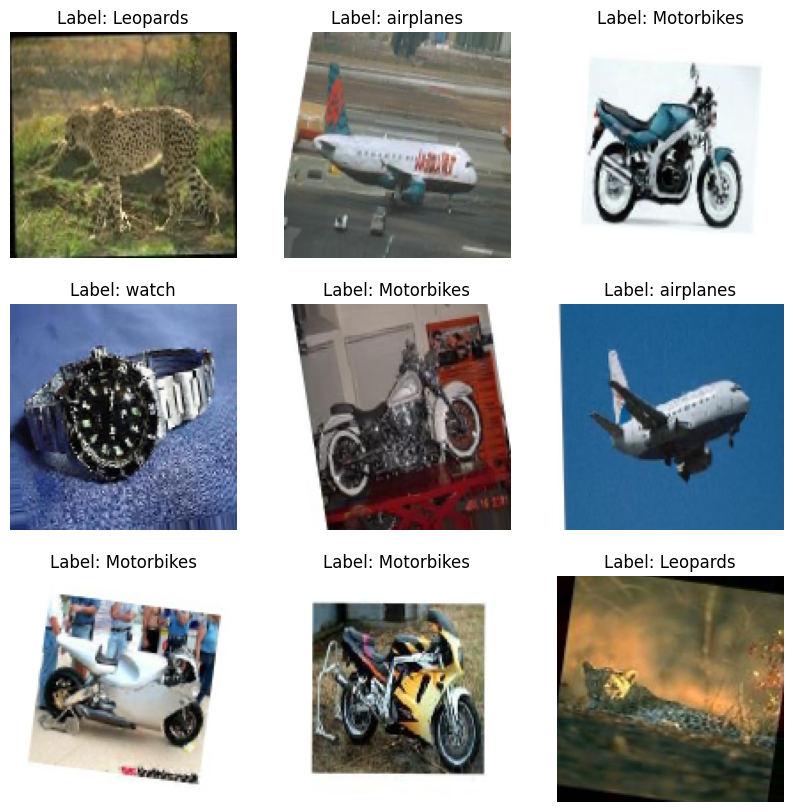

In [28]:
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Path ke dataset Anda (sesuaikan dengan path dataset yang digunakan)
dataset_path = '/content/caltech-101'  # Path yang benar sesuai dengan struktur dataset

# Kelas yang ingin dipilih
selected_classes = ['airplanes', 'Motorbikes', 'Leopards', 'watch']

# Menyiapkan ImageDataGenerator untuk augmentasi dan normalisasi
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisasi gambar
    rotation_range=10,  # Rotasi acak gambar
    fill_mode='nearest',  # Menangani piksel yang hilang setelah transformasi
    validation_split=0.2  # Menetapkan 20% data sebagai validation set
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Normalisasi untuk validasi dan testing

# Memastikan hanya memuat kelas yang terpilih
class_names = os.listdir(dataset_path)
print(f"Kelas yang tersedia: {class_names}")

# Pilih kelas yang ada di dalam selected_classes
valid_classes = [cls for cls in class_names if cls in selected_classes]
print(f"Kelas yang dipilih: {valid_classes}")

# Menggunakan flow_from_directory untuk memuat gambar dan labelnya
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),  # Ukuran gambar input
    batch_size=32,
    class_mode='categorical',  # Kategori untuk klasifikasi
    subset='training',  # Menentukan ini untuk training set
    classes=valid_classes  # Memuat hanya kelas yang terpilih
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # Menentukan ini untuk validation set
    classes=valid_classes  # Memuat hanya kelas yang terpilih
)

test_generator = test_datagen.flow_from_directory(
    dataset_path,  # folder test Anda
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    classes=valid_classes
)


# Cek beberapa sample dari train_generator
sample_images, sample_labels = next(train_generator)
print(f"Sample images shape: {sample_images.shape}")
print(f"Sample labels shape: {sample_labels.shape}")

# Visualisasi beberapa gambar training
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(f"Label: {valid_classes[sample_labels[i].argmax()]}")
    plt.axis('off')
plt.show()


## Modelling

In [59]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definisikan model CNN
model = models.Sequential([
    # Lapisan konvolusi pertama
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Lapisan konvolusi kedua
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Lapisan konvolusi ketiga
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Lapisan Flatten
    layers.Flatten(),

    # Lapisan Dense pertama
    layers.Dense(128, activation='relu'),


    # Lapisan output dengan softmax untuk klasifikasi 4 kelas
    layers.Dense(4, activation='softmax')
])

# Ringkasan model
model.summary()

# Kompilasi model dengan Adam optimizer dan sparse categorical crossentropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Melatih model menggunakan generator
history = model.fit(
    train_generator,  # Training set
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=18,  # Jumlah epoch
    validation_data=validation_generator,  # Validation set
    validation_steps=validation_generator.samples // validation_generator.batch_size
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.5873 - loss: 0.9668 - val_accuracy: 0.7604 - val_loss: 0.8276
Epoch 2/18
 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9375 - loss: 0.1241

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9375 - loss: 0.1241 - val_accuracy: 0.7708 - val_loss: 0.8457
Epoch 3/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.9564 - loss: 0.1049 - val_accuracy: 0.8229 - val_loss: 0.6738
Epoch 4/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9375 - loss: 0.1368 - val_accuracy: 0.8854 - val_loss: 0.3704
Epoch 5/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.9643 - loss: 0.1132 - val_accuracy: 0.9349 - val_loss: 0.2320
Epoch 6/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9062 - loss: 0.3378 - val_accuracy: 0.9271 - val_loss: 0.2733
Epoch 7/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.9905 - loss: 0.0431 - val_accuracy: 0.9089 - val_loss: 0.4910
Epoch 8/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9688 - loss: 0.0970 - val_accuracy: 0.9323 - val_loss: 0.3355
Epoch 9/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9759 - loss: 0.1030 - val_accuracy: 0.8333 - val_l

## Evaluasi dan Visualisasi

In [60]:
# Assuming you have a test_generator similar to train_generator and validation_generator
test_loss, test_accuracy = model.evaluate(validation_generator, verbose=1)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.9222 - loss: 0.5010
Test Accuracy: 93.10%


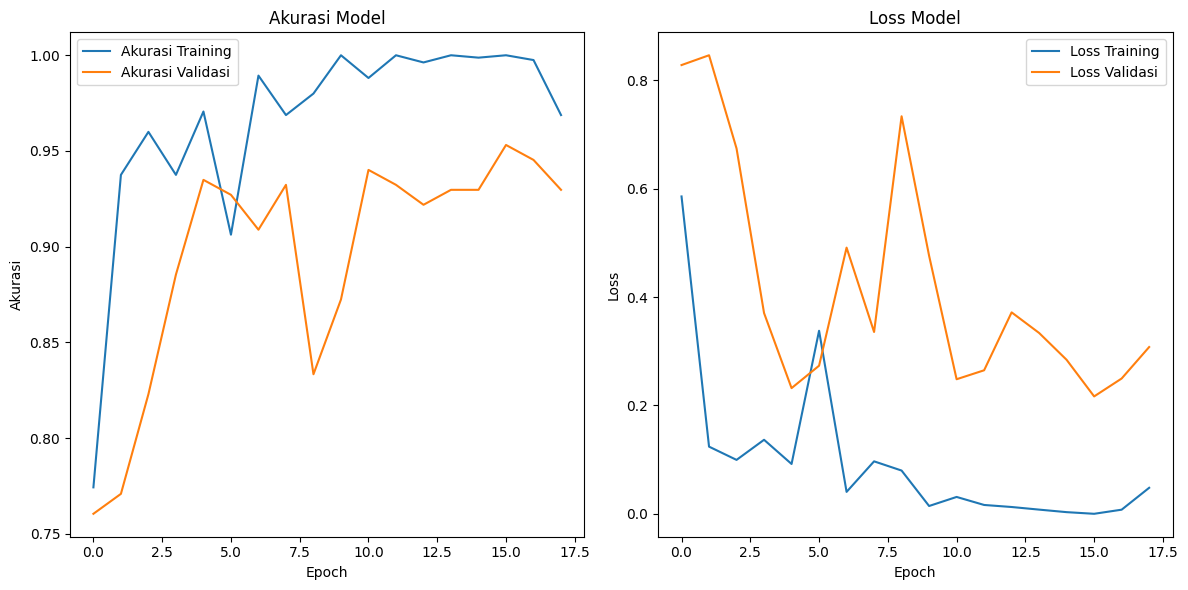

In [61]:
import matplotlib.pyplot as plt

# Visualisasi akurasi
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Visualisasi loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Tampilkan plot
plt.tight_layout()
plt.show()


## Konversi Model

SavedModel

In [62]:
pip install tensorflow tensorflowjs


In [64]:
import tensorflow as tf
import tensorflowjs as tfjs
import os

# 1. Simpan ke format .keras
model.save("model.keras")
print("✅ Model disimpan dalam format .keras")

# 2. Simpan ke format SavedModel (wajib pakai export)
saved_model_path = "saved_model/my_model"
os.makedirs(saved_model_path, exist_ok=True)
model.export(saved_model_path)
print("✅ Model disimpan dalam format SavedModel")

# 3. Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

# Simpan file TFLite
os.makedirs("tflite", exist_ok=True)
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)
print("✅ Model dikonversi ke TFLite")

# 4. Konversi ke TFJS
os.makedirs("tfjs_model", exist_ok=True)
tfjs.converters.convert_tf_saved_model(saved_model_path, "tfjs_model")
print("✅ Model dikonversi ke TensorFlow.js")


✅ Model disimpan dalam format .keras
Saved artifact at 'saved_model/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_170')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134283535479056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535480016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535480592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535481168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535480400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535481936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535481360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535482512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535482704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134283535478672: TensorSpec(shape=(), d

## Inference (Optional)

In [78]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Memuat model SavedModel
model = tf.saved_model.load('saved_model/my_model')

# Menentukan path gambar yang akan diprediksi
img_path = '/content/caltech-101/airplanes/image_0001.jpg'

# Memuat gambar dan mengubah ukuran sesuai input model (128, 128)
img = image.load_img(img_path, target_size=(128, 128))  # Sesuaikan dengan ukuran input model saat training

# Mengubah gambar menjadi array numpy
img_array = image.img_to_array(img)

# Normalisasi gambar
img_array = img_array / 255.0

# Menambahkan dimensi batch
img_array = np.expand_dims(img_array, axis=0)

# Melakukan prediksi menggunakan model SavedModel, provide input as keyword argument
infer = model.signatures["serving_default"]
predictions = infer(keras_tensor_170=tf.convert_to_tensor(img_array)) # Pass input as keyword argument

# Menampilkan hasil prediksi
# Accessing the output using 'output_0' key
predicted_class = np.argmax(predictions['output_0'][0].numpy(), axis=0)
class_labels = ['airplanes', 'Motorbikes', 'Leopards', 'watch']

print(f'Prediksi Kelas: {class_labels[predicted_class]}')

Prediksi Kelas: watch
